# MACHINE LEARNING — LAB 4
## Improving and Comparing Machine Learning Models

**Name:** Muhammad Hussain  
**Student ID:** 023-24-0225
**Section:** G  
**GitHub Profile:** https://github.com/muhammadhussainbscsf24-wq/ML-LABS
**Kaggle Profile:** https://www.kaggle.com/hussain456  
**Dataset:** Telco Customer Churn  
**Dataset Source:** Kaggle — WA_Fn-UseC_-Telco-Customer-Churn.csv

## Task 1

> Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("clean_churn.csv")

y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X:", X.shape)
print("y:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X: (7043, 30)
y: (7043,)
X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


C:\Users\musha\AppData\Local\Temp\ipykernel_16672\2097863034.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## Task 2

> Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

chosen_depth = 6

decision_tree = DecisionTreeClassifier(
    max_depth=chosen_depth,
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_pred = decision_tree.predict(X_test)

tree_metrics = {
    "accuracy": accuracy_score(y_test, tree_pred),
    "precision": precision_score(y_test, tree_pred),
    "recall": recall_score(y_test, tree_pred),
    "f1": f1_score(y_test, tree_pred)
}

pd.DataFrame([tree_metrics], index=["Decision Tree"]).round(4)

,accuracy,precision,recall,f1
Decision Tree,0.8006,0.6667,0.4973,0.5697


## Task 3

> Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state). Generate predictions on the test set.

In [3]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

print("Random Forest predictions:")
print(rf_pred[:20])

Random Forest predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


## Task 4

> In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [4]:
print("A Random Forest can generalize better because it combines many Decision Trees trained on different bootstrapped samples and feature selections, so the errors of individual trees can be reduced when their predictions are combined.")

A Random Forest can generalize better because it combines many Decision Trees trained on different bootstrapped samples and feature selections, so the errors of individual trees can be reduced when their predictions are combined.


## Task 5

> Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

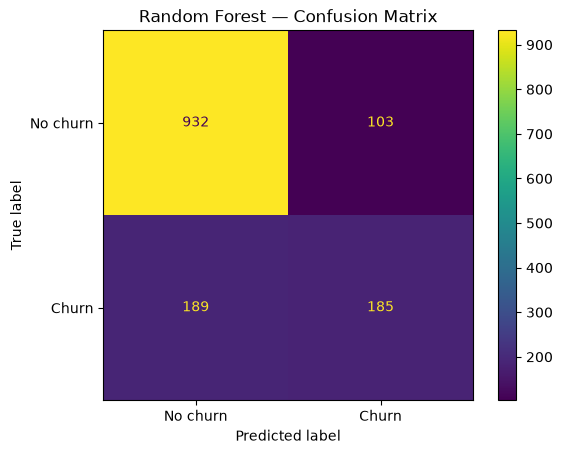

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred)
}

pd.DataFrame([rf_metrics], index=["Random Forest"]).round(4)

cm = confusion_matrix(y_test, rf_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn", "Churn"]
)
display.plot(values_format="d")
plt.title("Random Forest — Confusion Matrix")
plt.show()

## Task 6

> Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.

In [6]:
comparison = pd.DataFrame(
    [tree_metrics, rf_metrics],
    index=["Decision Tree", "Random Forest"]
)

comparison.round(4)

,accuracy,precision,recall,f1
Decision Tree,0.8006,0.6667,0.4973,0.5697
Random Forest,0.7928,0.6424,0.4947,0.5589


## Task 7

> Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

In [7]:
comparison_display = comparison.copy()

best_by_metric = comparison_display.idxmax()
difference = comparison_display.loc["Random Forest"] - comparison_display.loc["Decision Tree"]

print("Better model by metric:")
print(best_by_metric)

print("\nDifference between Random Forest and Decision Tree:")
print(difference.round(4))

print("\nBecause the churn classes are imbalanced, recall and F1-score are especially important. Recall focuses on how many actual churners are caught, while F1 balances recall with precision.")

Better model by metric:
accuracy     Decision Tree
precision    Decision Tree
recall       Decision Tree
f1           Decision Tree
dtype: str

Difference between Random Forest and Decision Tree:
accuracy    -0.0078
precision   -0.0243
recall      -0.0027
f1          -0.0108
dtype: float64

Because the churn classes are imbalanced, recall and F1-score are especially important. Recall focuses on how many actual churners are caught, while F1 balances recall with precision.


## Task 8

> Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.

In [8]:
from sklearn.model_selection import cross_val_score

tree_cv_scores = cross_val_score(
    decision_tree,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="f1"
)

cv_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Mean F1": [tree_cv_scores.mean(), rf_cv_scores.mean()],
    "Standard Deviation": [tree_cv_scores.std(), rf_cv_scores.std()]
})

cv_results.round(4)

,Model,Mean F1,Standard Deviation
0,Decision Tree,0.5675,0.0245
1,Random Forest,0.5536,0.0187


## Task 9

> How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion?

In [9]:
single_split_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test F1": [tree_metrics["f1"], rf_metrics["f1"]],
    "Cross-Validated Mean F1": [tree_cv_scores.mean(), rf_cv_scores.mean()],
    "Cross-Validated Std": [tree_cv_scores.std(), rf_cv_scores.std()]
})

single_split_results.round(4)

print("\nThe single train/test split gives one performance estimate, while 5-fold cross-validation gives performance across five different splits. The cross-validated mean and standard deviation provide a broader view of model performance and how stable the F1-score is across folds.")


The single train/test split gives one performance estimate, while 5-fold cross-validation gives performance across five different splits. The cross-validated mean and standard deviation provide a broader view of model performance and how stable the F1-score is across folds.


## Task 10

> Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination.

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated F1: 0.5708


## Task 11

> Report the best hyperparameters found and the corresponding cross-validated score.

In [11]:
print("Best hyperparameters:")
print(grid_search.best_params_)

print("\nBest cross-validated F1-score:")
print(round(grid_search.best_score_, 4))

Best hyperparameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validated F1-score:
0.5708


## Task 12

> Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [12]:
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)

tuned_metrics = {
    "accuracy": accuracy_score(y_test, tuned_pred),
    "precision": precision_score(y_test, tuned_pred),
    "recall": recall_score(y_test, tuned_pred),
    "f1": f1_score(y_test, tuned_pred)
}

pd.DataFrame([tuned_metrics], index=["Tuned Random Forest"]).round(4)

,accuracy,precision,recall,f1
Tuned Random Forest,0.8048,0.6623,0.5401,0.595


## Task 13

> Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

In [13]:
final_comparison = pd.DataFrame(
    [tree_metrics, rf_metrics, tuned_metrics],
    index=["Decision Tree", "Random Forest", "Tuned Random Forest"]
)

final_comparison.round(4)

,accuracy,precision,recall,f1
Decision Tree,0.8006,0.6667,0.4973,0.5697
Random Forest,0.7928,0.6424,0.4947,0.5589
Tuned Random Forest,0.8048,0.6623,0.5401,0.5950


## Task 14

> Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification.

In [14]:
model_scores = final_comparison.copy()

best_model_by_f1 = model_scores["f1"].idxmax()
best_model_by_recall = model_scores["recall"].idxmax()

print("Highest F1-score:", best_model_by_f1)
print("Highest recall:", best_model_by_recall)

if best_model_by_f1 == "Tuned Random Forest":
    final_model = tuned_model
    final_model_name = "Tuned Random Forest"
elif best_model_by_f1 == "Random Forest":
    final_model = random_forest
    final_model_name = "Random Forest"
else:
    final_model = decision_tree
    final_model_name = "Decision Tree"

print("\nFinal model:", final_model_name)
print("The final model is selected using held-out test-set evidence, with F1-score considered alongside recall and the other required metrics rather than using training performance alone.")

Highest F1-score: Tuned Random Forest
Highest recall: Tuned Random Forest

Final model: Tuned Random Forest
The final model is selected using held-out test-set evidence, with F1-score considered alongside recall and the other required metrics rather than using training performance alone.


## Task 15

> Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

Top 5 features:
tenure                            0.191132
TotalCharges                      0.157462
MonthlyCharges                    0.120849
InternetService_Fiber optic       0.064952
PaymentMethod_Electronic check    0.060395
dtype: float64


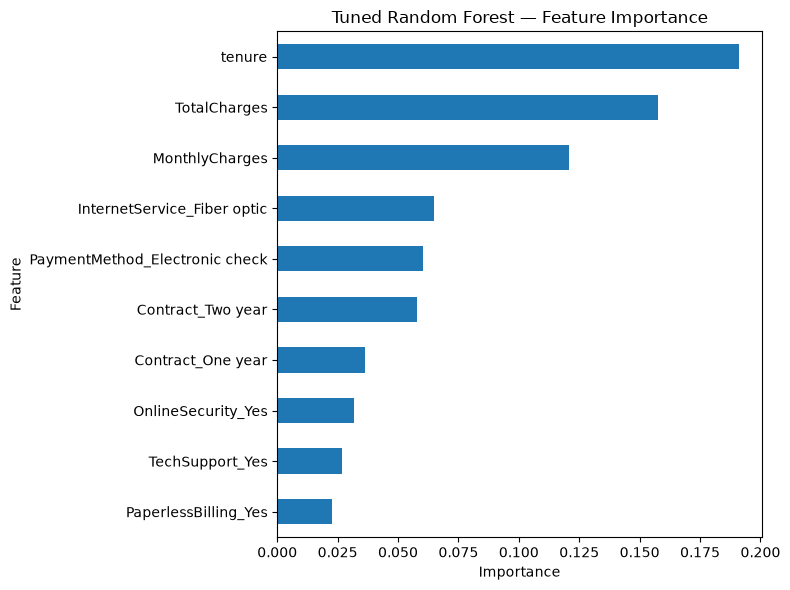


The top features are the features assigned the largest relative importance by the final tree-based model. These can be compared with the patterns observed in the earlier EDA and Decision Tree analysis.


In [15]:
import matplotlib.pyplot as plt

importances = final_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 features:")
print(feature_importance.head(5))

plt.figure(figsize=(8, 6))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"{final_model_name} — Feature Importance")
plt.tight_layout()
plt.show()

print("\nThe top features are the features assigned the largest relative importance by the final tree-based model. These can be compared with the patterns observed in the earlier EDA and Decision Tree analysis.")

## Task 16

> Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv.

In [16]:
submission = pd.DataFrame({
    "customerID": df.loc[X_test.index, "customerID"] if "customerID" in df.columns else X_test.index,
    "Churn": final_model.predict(X_test)
})

submission["Churn"] = submission["Churn"].map({0: "No", 1: "Yes"})
submission.to_csv("submission.csv", index=False)

submission.head()

,customerID,Churn
0,437,No
1,2280,Yes
2,2235,No
3,4460,No
4,3761,No


## Task 17

> Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations.

In [17]:
final_accuracy = final_comparison.loc[final_model_name, "accuracy"]
final_precision = final_comparison.loc[final_model_name, "precision"]
final_recall = final_comparison.loc[final_model_name, "recall"]
final_f1 = final_comparison.loc[final_model_name, "f1"]

print(
    f"I ultimately selected the {final_model_name} because it provided the strongest evidence across the required evaluation metrics. "
    f"Its test accuracy was {final_accuracy:.2%}, precision was {final_precision:.2%}, recall was {final_recall:.2%}, and F1-score was {final_f1:.2%}. "
    f"Compared with the Lab 3 Decision Tree at max_depth=6, the final model provides a basis for judging whether the ensemble approach improved churn prediction. "
    f"The model still has limitations because it can miss some actual churners and the class imbalance has not been handled directly. "
    f"Further improvement would require testing additional approaches and validating their performance carefully."
)

I ultimately selected the Tuned Random Forest because it provided the strongest evidence across the required evaluation metrics. Its test accuracy was 80.48%, precision was 66.23%, recall was 54.01%, and F1-score was 59.50%. Compared with the Lab 3 Decision Tree at max_depth=6, the final model provides a basis for judging whether the ensemble approach improved churn prediction. The model still has limitations because it can miss some actual churners and the class imbalance has not been handled directly. Further improvement would require testing additional approaches and validating their performance carefully.


## Task 18

> What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

In [18]:
print("With more time, I would try additional algorithms, deeper but carefully controlled hyperparameter tuning, and methods that directly address the class imbalance. I would compare those approaches using recall and F1-score along with the other required metrics, and I would use cross-validation to check whether any improvement is consistent.")

With more time, I would try additional algorithms, deeper but carefully controlled hyperparameter tuning, and methods that directly address the class imbalance. I would compare those approaches using recall and F1-score along with the other required metrics, and I would use cross-validation to check whether any improvement is consistent.
